In [1]:
# Part 2 of regression in python with statsmodel

In [2]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from itertools import product
import matplotlib.pyplot as plt
from scipy.optimize import minimize
warnings.filterwarnings("ignore")
from statsmodels.formula.api import ols


In [3]:
taiwan_df = pd.read_csv('Data/taiwan_realestate.csv')

taiwan_df.head()

,No,TransactionDate,HouseAge,DistanceToMRT,NumberConvenienceStores,Latitude,Longitude,PriceOfUnitArea
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
taiwan_df.isna().sum()

No                         0
TransactionDate            0
HouseAge                   0
DistanceToMRT              0
NumberConvenienceStores    0
Latitude                   0
Longitude                  0
PriceOfUnitArea            0
dtype: int64

**Parallel slopes linear regression:** there is one numeric explanatory variable and one categorical explanatory variable and it is called parallel slopes due to the shape of the predictions

In [5]:
import pandas as pd

# Create age categories
taiwan_df["HouseAge"] = pd.cut(
    taiwan_df["HouseAge"],
    bins=[0, 15, 30, 45],
    labels=[
        "house_age_years[0 to 15]",
        "house_age_years[15 to 30]",
        "house_age_years[30 to 45]"
    ],
    include_lowest=True
)

print(taiwan_df.head())

   No  TransactionDate                   HouseAge  DistanceToMRT  \
0   1         2012.917  house_age_years[30 to 45]       84.87882   
1   2         2012.917  house_age_years[15 to 30]      306.59470   
2   3         2013.583   house_age_years[0 to 15]      561.98450   
3   4         2013.500   house_age_years[0 to 15]      561.98450   
4   5         2012.833   house_age_years[0 to 15]      390.56840   

   NumberConvenienceStores  Latitude  Longitude  PriceOfUnitArea  
0                       10  24.98298  121.54024             37.9  
1                        9  24.98034  121.53951             42.2  
2                        5  24.98746  121.54391             47.3  
3                        5  24.98746  121.54391             54.8  
4                        5  24.97937  121.54245             43.1  


In [6]:
# Fit a linear regression of PriceOfUnitArea vs. NumberConvenienceStores
mdl_price_vs_conv = ols("PriceOfUnitArea ~ NumberConvenienceStores",
                        data=taiwan_df).fit()
print(mdl_price_vs_conv.params)

Intercept                  27.181105
NumberConvenienceStores     2.637653
dtype: float64


In [7]:
# Fit a linear regression of PriceOfUnitArea vs. HouseAge, no intercept
mdl_price_vs_age = ols("PriceOfUnitArea ~ HouseAge + 0", data=taiwan_df).fit()
print(mdl_price_vs_age.params)

HouseAge[house_age_years[0 to 15]]     41.619792
HouseAge[house_age_years[15 to 30]]    32.643750
HouseAge[house_age_years[30 to 45]]    37.812766
dtype: float64


In [8]:
# Fit a linear regression of PriceOfUnitArea vs. NumberConvenienceStores plus HouseAge, no intercept
mdl_price_vs_both = ols("PriceOfUnitArea ~ NumberConvenienceStores + HouseAge + 0", data=taiwan_df).fit()

# Print the coefficients
print(mdl_price_vs_both.params)

HouseAge[house_age_years[0 to 15]]     30.972185
HouseAge[house_age_years[15 to 30]]    23.444381
HouseAge[house_age_years[30 to 45]]    25.008209
NumberConvenienceStores                 2.610907
dtype: float64


For each additional nearby convenience store, the expected house price, in TWD per square meter, increases by 2.61.
For a house aged 0 to 15 years with zero nearby convenience stores, the expected house price is 30.97 TWD per square meter.

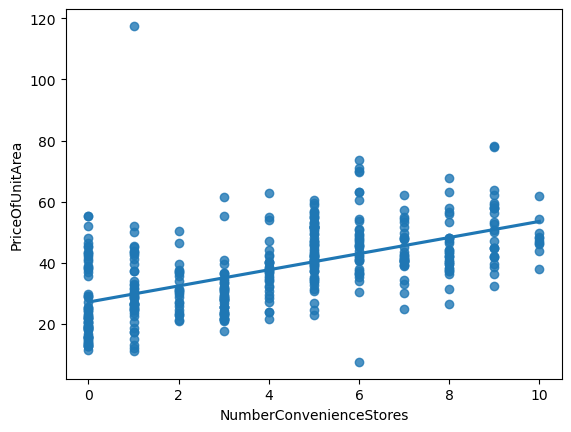

In [9]:
# Create a scatter plot with linear trend line of PriceOfUnitArea vs. NumberConvenienceStores
sns.regplot(x = 'NumberConvenienceStores', y = 'PriceOfUnitArea', data = taiwan_df, ci = None)

# Show the plot
plt.show()

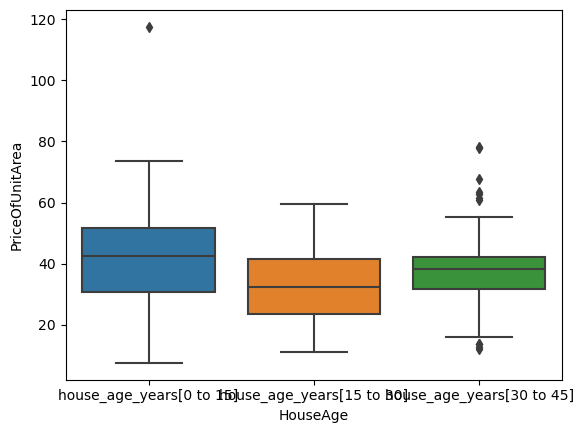

In [10]:
# With a single categorical explanatory variable, the predictions are the means of each category.

# Create a boxplot of price_twd_msq vs. house_age_years
sns.boxplot(x= 'HouseAge', y = 'PriceOfUnitArea', data = taiwan_df)

# Show the plot
plt.show()

In [11]:
# Extract the model coefficients, coeffs
coeffs = mdl_price_vs_both.params

# Print coeffs
print(coeffs)

# Assign each of the coeffs
ic_0_15, ic_15_30, ic_30_45, slope = coeffs

HouseAge[house_age_years[0 to 15]]     30.972185
HouseAge[house_age_years[15 to 30]]    23.444381
HouseAge[house_age_years[30 to 45]]    25.008209
NumberConvenienceStores                 2.610907
dtype: float64


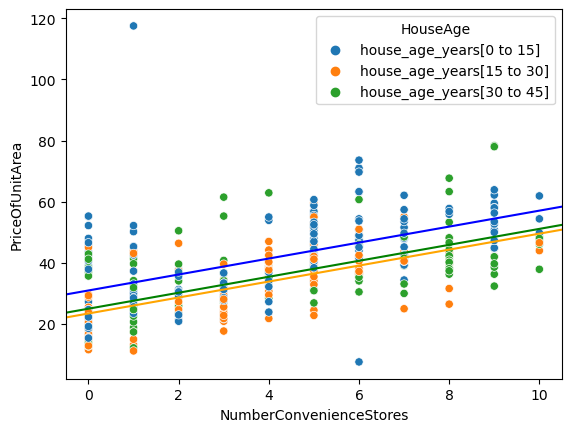

In [12]:
# Draw a scatter plot of price_twd_msq vs. n_convenience, colored by house_age_years
sns.scatterplot(x="NumberConvenienceStores",
                y="PriceOfUnitArea",
                hue="HouseAge",
                data=taiwan_df)

# Add three parallel lines for each category of house_age_years
# Color the line for ic_0_15 blue
plt.axline(xy1=(0, ic_0_15), slope=slope, color="blue")
# Color the line for ic_15_30 orange
plt.axline(xy1=(0, ic_15_30), slope=slope, color="orange")
# Color the line for ic_30_45 green
plt.axline(xy1=(0, ic_30_45), slope=slope, color="green")

# Show the plot
plt.show()

The "parallel slope" model name comes from the fact that the prediction for each category is a slope, and all those slopes are parallel. The plot allows us to see that newer houses are on average more expensive than houses older than 15 years.

In [13]:
# Create NumberConvenienceStores as a range of numbers from 0 to 10
NumberConvenienceStores = np.arange(0, 11)

# Extract the unique values of HouseAge
HouseAge = taiwan_df["HouseAge"].unique()

# Create p as all combinations of values of NumberConvenienceStores and HouseAge
p = product(NumberConvenienceStores, HouseAge)

# Transform p to a DataFrame and name the columns
explanatory_data = pd.DataFrame(p, columns=['NumberConvenienceStores', 'HouseAge'])

# Add predictions to the DataFrame
prediction_data = explanatory_data.assign(PriceOfUnitArea = mdl_price_vs_both.predict(explanatory_data))

print(prediction_data)

    NumberConvenienceStores                   HouseAge  PriceOfUnitArea
0                         0  house_age_years[30 to 45]        25.008209
1                         0  house_age_years[15 to 30]        23.444381
2                         0   house_age_years[0 to 15]        30.972185
3                         1  house_age_years[30 to 45]        27.619117
4                         1  house_age_years[15 to 30]        26.055288
5                         1   house_age_years[0 to 15]        33.583092
6                         2  house_age_years[30 to 45]        30.230024
7                         2  house_age_years[15 to 30]        28.666196
8                         2   house_age_years[0 to 15]        36.194000
9                         3  house_age_years[30 to 45]        32.840932
10                        3  house_age_years[15 to 30]        31.277103
11                        3   house_age_years[0 to 15]        38.804907
12                        4  house_age_years[30 to 45]        35

In [14]:
# Extract the model coefficients, coeffs
coeffs = mdl_price_vs_both.params

# Print coeffs
print(coeffs)

# Assign each of the coeffs
ic_0_15, ic_15_30, ic_30_45, slope  = coeffs

HouseAge[house_age_years[0 to 15]]     30.972185
HouseAge[house_age_years[15 to 30]]    23.444381
HouseAge[house_age_years[30 to 45]]    25.008209
NumberConvenienceStores                 2.610907
dtype: float64


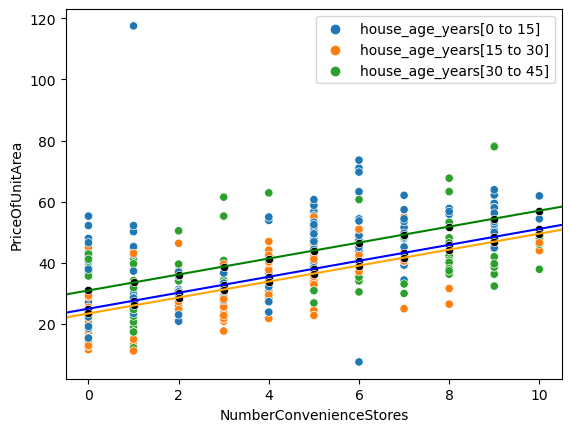

In [15]:
# Extract the model coefficients, coeffs
coeffs = mdl_price_vs_both.params

# Assign each of the coeffs
ic_0_15, ic_15_30, ic_30_45, slope = coeffs

# Create the parallel slopes plot
plt.axline(xy1=(0, ic_0_15), slope=slope, color="green")
plt.axline(xy1=(0, ic_15_30), slope=slope, color="orange")
plt.axline(xy1=(0, ic_30_45), slope=slope, color="blue")
sns.scatterplot(x="NumberConvenienceStores",
                y="PriceOfUnitArea",
                hue="HouseAge",
                data=taiwan_df)

# Add the predictions in black
sns.scatterplot(x = 'NumberConvenienceStores', y = 'PriceOfUnitArea', data = prediction_data, color = 'black')

plt.show()

The predictions lie exactly on the trend lines.

In [16]:
# Define conditions
conditions = [
    explanatory_data["HouseAge"] == "0 to 15",
    explanatory_data["HouseAge"] == "15 to 30",
    explanatory_data["HouseAge"] == "30 to 45"
]

# Define choices
choices = [ic_0_15, ic_15_30, ic_30_45]

# Create array of intercepts for each house_age_year category
intercept = np.select(conditions, choices)

# Create prediction_data with columns intercept and PriceOfUnitArea
prediction_data = explanatory_data.assign(
    intercept = intercept,
    PriceOfUnitArea = intercept + slope * explanatory_data['NumberConvenienceStores'])
	
print(prediction_data)

    NumberConvenienceStores                   HouseAge  intercept  \
0                         0  house_age_years[30 to 45]        0.0   
1                         0  house_age_years[15 to 30]        0.0   
2                         0   house_age_years[0 to 15]        0.0   
3                         1  house_age_years[30 to 45]        0.0   
4                         1  house_age_years[15 to 30]        0.0   
5                         1   house_age_years[0 to 15]        0.0   
6                         2  house_age_years[30 to 45]        0.0   
7                         2  house_age_years[15 to 30]        0.0   
8                         2   house_age_years[0 to 15]        0.0   
9                         3  house_age_years[30 to 45]        0.0   
10                        3  house_age_years[15 to 30]        0.0   
11                        3   house_age_years[0 to 15]        0.0   
12                        4  house_age_years[30 to 45]        0.0   
13                        4  house

**The coefficient of determination** is a measure of how well the linear regression line fits the observed values

In [17]:
# Print the coeffs of determination for mdl_price_vs_conv
print("rsquared_conv: ", mdl_price_vs_conv.rsquared)
print("rsquared_adj_conv: ", mdl_price_vs_conv.rsquared_adj)

# Print the coeffs of determination for mdl_price_vs_age
print("rsquared_age: ", mdl_price_vs_age.rsquared)
print("rsquared_adj_age: ", mdl_price_vs_age.rsquared_adj)

# Print the coeffs of determination for mdl_price_vs_both
print("rsquared_both: ", mdl_price_vs_both.rsquared)
print("rsquared_adj_both: ", mdl_price_vs_both.rsquared_adj)

rsquared_conv:  0.32604660851305056
rsquared_adj_conv:  0.3244107993104123
rsquared_age:  0.08097072414341477
rsquared_adj_age:  0.07649856221710538
rsquared_both:  0.3912173905498687
rsquared_adj_both:  0.38676288365145306


When both explanatory variables are included in the model, the adjusted coefficient of determination is higher, resulting in a better fit.
* The adjusted R^2 of mdl_price_vs_age indicates that the model explains approximately 7.7% of the variation in house prices.
* The adjusted R^2 of mdl_price_vs_conv indicates that the model explains approximately 32.4% of the variation in house prices.
* The adjusted R^2 of mdl_price_vs_both indicates that the model explains approximately 38.7% of the variation in house prices, making it the best-fitting model of the three because it explains the largest proportion of the variability in house prices while accounting for the number of predictors.

The other common metric for assessing model fit is the residual standard error (RSE), which measures the typical size of the residuals.

In [18]:
# Print the RSE for mdl_price_vs_conv
print("rse_conv: ", np.sqrt(mdl_price_vs_conv.mse_resid))

# Print the RSE for mdl_price_vs_age
print("rse_age: ", np.sqrt(mdl_price_vs_age.mse_resid))

# Print RSE for mdl_price_vs_both
print("rse_both: ", np.sqrt(mdl_price_vs_both.mse_resid))

rse_conv:  11.183748258038918
rse_age:  13.075696189242715
rse_both:  10.655166726565064


By including both explanatory variables in the model, a lower RSE was achieved, indicating a smaller difference between the predicted responses and the actual responses. Therefore, the rse suggests the mdl_price_vs_both gives a better fit.

In [19]:
# Filter for rows where house age is 0 to 15 years
taiwan_0_to_15 = taiwan_df[taiwan_df["HouseAge"] == "house_age_years[0 to 15]"]

# Filter for rows where house age is 15 to 30 years
taiwan_15_to_30 = taiwan_df[taiwan_df["HouseAge"] == "house_age_years[15 to 30]"]

# Filter for rows where house age is 30 to 45 years
taiwan_30_to_45 = taiwan_df[taiwan_df["HouseAge"] == "house_age_years[30 to 45]"]

# Fit the models
mdl_0_to_15 = ols("PriceOfUnitArea ~ NumberConvenienceStores", data=taiwan_0_to_15).fit()
mdl_15_to_30 = ols("PriceOfUnitArea ~ NumberConvenienceStores", data=taiwan_15_to_30).fit()
mdl_30_to_45 = ols("PriceOfUnitArea ~ NumberConvenienceStores", data=taiwan_30_to_45).fit()

# Print the coefficients
print(mdl_0_to_15.params)
print(mdl_15_to_30.params)
print(mdl_30_to_45.params)

Intercept                  30.419799
NumberConvenienceStores     2.746358
dtype: float64
Intercept                  22.739019
NumberConvenienceStores     2.811099
dtype: float64
Intercept                  26.967000
NumberConvenienceStores     2.211501
dtype: float64


The three models show that the number of nearby convenience stores is positively associated with house prices for all house age groups. Each additional convenience store is associated with an increase of approximately 2.75, 2.81, and 2.21 units in price for houses aged 0–15, 15–30, and 30–45 years, respectively. This suggests that convenience stores have the strongest positive association with the prices of 15–30-year-old houses and the weakest association with 30–45-year-old houses. Overall, more nearby convenience stores are associated with higher house prices regardless of house age.

In [20]:
# Create explanatory_data, setting no. of conv stores from  0 to 10
explanatory_data = pd.DataFrame({'n_convenience': np.arange(0, 11)})

# Add column of predictions using "0 to 15" model and explanatory data 
prediction_data_0_to_15 = explanatory_data.assign(price_twd_msq = mdl_0_to_15.predict(explanatory_data))

# Same again, with "15 to 30"
prediction_data_15_to_30 = explanatory_data.assign(price_twd_msq = mdl_15_to_30.predict(explanatory_data))

# Same again, with "30 to 45"
prediction_data_30_to_45 = explanatory_data.assign(price_twd_msq = mdl_30_to_45.predict(explanatory_data))

print(prediction_data_0_to_15)
print(prediction_data_15_to_30)
print(prediction_data_30_to_45)

    n_convenience  price_twd_msq
0               0      30.419799
1               1      33.166158
2               2      35.912516
3               3      38.658874
4               4      41.405232
5               5      44.151591
6               6      46.897949
7               7      49.644307
8               8      52.390665
9               9      55.137024
10             10      57.883382
    n_convenience  price_twd_msq
0               0      22.739019
1               1      25.550118
2               2      28.361217
3               3      31.172316
4               4      33.983414
5               5      36.794513
6               6      39.605612
7               7      42.416710
8               8      45.227809
9               9      48.038908
10             10      50.850006
    n_convenience  price_twd_msq
0               0      26.967000
1               1      29.178501
2               2      31.390002
3               3      33.601503
4               4      35.813004
5         

In [21]:
# Filter for each house age category
taiwan_0_to_15 = taiwan_df[taiwan_df["HouseAge"] == "[0 to 15]"]
taiwan_15_to_30 = taiwan_df[taiwan_df["HouseAge"] == "[15 to 30]"]
taiwan_30_to_45 = taiwan_df[taiwan_df["HouseAge"] == "[30 to 45]"]

# Concatenate into one DataFrame
prediction_data = pd.concat(
    [taiwan_0_to_15, taiwan_15_to_30, taiwan_30_to_45],
    ignore_index=True
)

print(prediction_data)

Empty DataFrame
Columns: [No, TransactionDate, HouseAge, DistanceToMRT, NumberConvenienceStores, Latitude, Longitude, PriceOfUnitArea]
Index: []


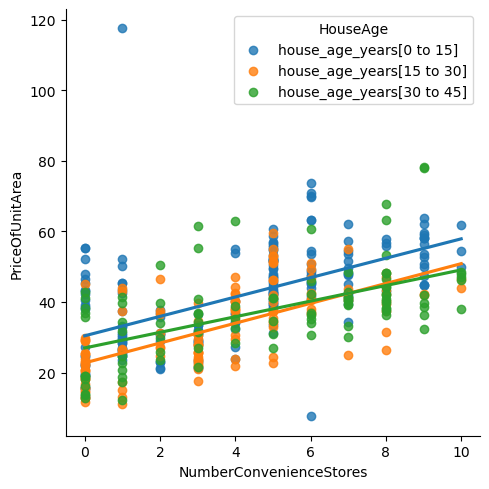

In [22]:
# Plot the trend lines of price_twd_msq vs. n_convenience for each house age category
sns.lmplot(x="NumberConvenienceStores",
     y="PriceOfUnitArea",
     data=taiwan_df,
     hue="HouseAge",
     ci=None,
     legend_out=False)

# Add a scatter plot for prediction_data
sns.scatterplot(
    x="NumberConvenienceStores",
    y="PriceOfUnitArea",
    data=prediction_data,
    hue="HouseAge",
    legend=False
)

plt.show()

In [23]:
mdl_all_ages = ols(
    "PriceOfUnitArea ~ NumberConvenienceStores + HouseAge",
    data=taiwan_df

).fit()

In [24]:
# Print the coeff. of determination for mdl_all_ages
print("R-squared for mdl_all_ages: ", mdl_all_ages.rsquared)

# Print the coeff. of determination for mdl_0_to_15
print("R-squared for mdl_0_to_15: ", mdl_0_to_15.rsquared)

# Print the coeff. of determination for mdl_15_to_30
print("R-squared for mdl_15_to_30: ", mdl_15_to_30.rsquared)

# Print the coeff. of determination for mdl_30_to_45
print("R-squared for mdl_30_to_45: ", mdl_30_to_45.rsquared)

R-squared for mdl_all_ages:  0.3912173905498687
R-squared for mdl_0_to_15:  0.30870318109309525
R-squared for mdl_15_to_30:  0.436399044059658
R-squared for mdl_30_to_45:  0.317547587985463


In [25]:
# Print the RSE for mdl_all_ages
print("RSE for mdl_all_ages: ", np.sqrt(mdl_all_ages.mse_resid))

# Print the RSE for mdl_0_to_15
print("RSE for mdl_0_to_15: ", np.sqrt(mdl_0_to_15.mse_resid))

# Print the RSE for mdl_15_to_30
print("RSE for mdl_15_to_30: ", np.sqrt(mdl_15_to_30.mse_resid))

# Print the RSE for mdl_30_to_45
print("RSE for mdl_30_to_45: ", np.sqrt(mdl_30_to_45.mse_resid))


RSE for mdl_all_ages:  10.655166726565064
RSE for mdl_0_to_15:  11.820739346646043
RSE for mdl_15_to_30:  8.613226228887866
RSE for mdl_30_to_45:  10.646604519060766


In [26]:
# Model price vs both with an interaction using "times" syntax
mdl_price_vs_both_inter = ols("PriceOfUnitArea ~ NumberConvenienceStores * HouseAge", data = taiwan_df).fit()

# Print the coefficients
print(mdl_price_vs_both_inter.params)

Intercept                                                        30.419799
HouseAge[T.house_age_years[15 to 30]]                            -7.680780
HouseAge[T.house_age_years[30 to 45]]                            -3.452799
NumberConvenienceStores                                           2.746358
NumberConvenienceStores:HouseAge[T.house_age_years[15 to 30]]     0.064740
NumberConvenienceStores:HouseAge[T.house_age_years[30 to 45]]    -0.534857
dtype: float64


In [27]:
# Model price vs. both with an interaction using "colon" syntax
mdl_price_vs_both_inter = ols("PriceOfUnitArea ~ NumberConvenienceStores + HouseAge + NumberConvenienceStores:HouseAge", data =taiwan_df ).fit()

# Print the coefficients
print(mdl_price_vs_both_inter.params)

Intercept                                                        30.419799
HouseAge[T.house_age_years[15 to 30]]                            -7.680780
HouseAge[T.house_age_years[30 to 45]]                            -3.452799
NumberConvenienceStores                                           2.746358
NumberConvenienceStores:HouseAge[T.house_age_years[15 to 30]]     0.064740
NumberConvenienceStores:HouseAge[T.house_age_years[30 to 45]]    -0.534857
dtype: float64


In [28]:
# Model price vs. house age plus an interaction, no intercept
mdl_readable_inter = ols("PriceOfUnitArea ~ HouseAge + NumberConvenienceStores:HouseAge + 0",
                         data=taiwan_df).fit()

# Print the coefficients for mdl_0_to_15
print("mdl_0_to_15 coefficients:", "\n", mdl_0_to_15.params)

# Print the coefficients for mdl_15_to_30
print("mdl_15_to_30 coefficients:", "\n", mdl_15_to_30.params)

# Print the coefficients for mdl_30_to_45
print("mdl_30_to_45 coefficients:", "\n", mdl_30_to_45.params)


mdl_0_to_15 coefficients: 
 Intercept                  30.419799
NumberConvenienceStores     2.746358
dtype: float64
mdl_15_to_30 coefficients: 
 Intercept                  22.739019
NumberConvenienceStores     2.811099
dtype: float64
mdl_30_to_45 coefficients: 
 Intercept                  26.967000
NumberConvenienceStores     2.211501
dtype: float64


In [29]:
# Print the coefficients for mdl_readable_inter
print("\n", "mdl_readable_inter coefficients:", "\n", mdl_readable_inter.params)


 mdl_readable_inter coefficients: 
 HouseAge[house_age_years[0 to 15]]                             30.419799
HouseAge[house_age_years[15 to 30]]                            22.739019
HouseAge[house_age_years[30 to 45]]                            26.967000
NumberConvenienceStores:HouseAge[house_age_years[0 to 15]]      2.746358
NumberConvenienceStores:HouseAge[house_age_years[15 to 30]]     2.811099
NumberConvenienceStores:HouseAge[house_age_years[30 to 45]]     2.211501
dtype: float64


In [30]:
# Create NumberConvenienceStores values from 0 to 10
n_convenience = np.arange(0, 11)

# Get unique house age categories
house_age_years = taiwan_df["HouseAge"].unique()

# Create all combinations
p = product(n_convenience, house_age_years)

# Create explanatory DataFrame with the SAME column names as the model
explanatory_data = pd.DataFrame(
    p,
    columns=["NumberConvenienceStores", "HouseAge"]
)

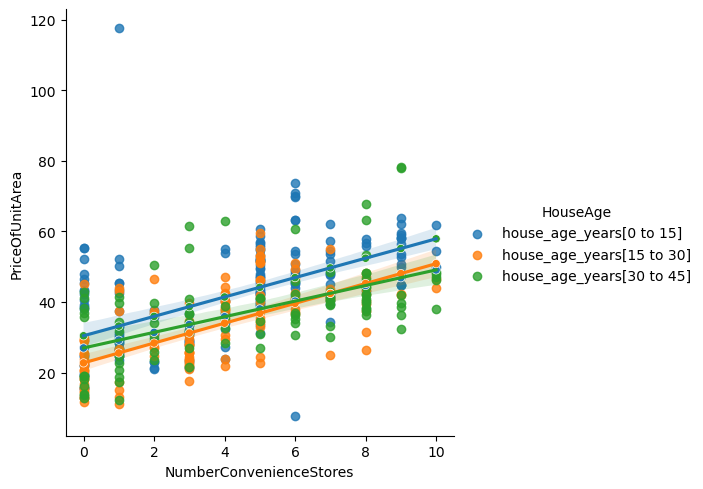

In [31]:
# Generate predictions
prediction_data = explanatory_data.assign(
    PriceOfUnitArea=mdl_price_vs_both_inter.predict(explanatory_data)
)

# Plot the original data
sns.lmplot(
    x="NumberConvenienceStores",
    y="PriceOfUnitArea",
    hue="HouseAge",
    data=taiwan_df
)

# Add a scatter plot for prediction_data
sns.scatterplot(
    x="NumberConvenienceStores",
    y="PriceOfUnitArea",
    hue="HouseAge",
    data=prediction_data,
    legend=False
)

plt.show()

In [32]:
# Get the coefficients from mdl_price_vs_both_inter
coeffs = mdl_price_vs_both_inter.params

# Assign each of the elements of coeffs
ic_0_15, ic_15_30, ic_30_45, slope_0_15, slope_15_30, slope_30_45 = coeffs

# Create conditions
conditions = [
    explanatory_data["HouseAge"] == "[0 to 15]",
    explanatory_data["HouseAge"] == "[15 to 30]",
    explanatory_data["HouseAge"] == "[30 to 45]"
]

# Create intercept_choices
intercept_choices = [ic_0_15, ic_15_30, ic_30_45]

# Create slope_choices
slope_choices = [slope_0_15, slope_15_30, slope_30_45]

# Create intercept and slope
intercept =  np.select(conditions, intercept_choices)
slope = np.select(conditions, slope_choices)

# Create prediction_data with columns intercept and price_twd_msq
prediction_data = explanatory_data.assign(
    PriceOfUnitArea = intercept + slope * explanatory_data["NumberConvenienceStores"]
)

# Print it
print(prediction_data)

    NumberConvenienceStores                   HouseAge  PriceOfUnitArea
0                         0  house_age_years[30 to 45]              0.0
1                         0  house_age_years[15 to 30]              0.0
2                         0   house_age_years[0 to 15]              0.0
3                         1  house_age_years[30 to 45]              0.0
4                         1  house_age_years[15 to 30]              0.0
5                         1   house_age_years[0 to 15]              0.0
6                         2  house_age_years[30 to 45]              0.0
7                         2  house_age_years[15 to 30]              0.0
8                         2   house_age_years[0 to 15]              0.0
9                         3  house_age_years[30 to 45]              0.0
10                        3  house_age_years[15 to 30]              0.0
11                        3   house_age_years[0 to 15]              0.0
12                        4  house_age_years[30 to 45]          

Intercept        45.851427
DistanceToMRT    -0.007262
dtype: float64


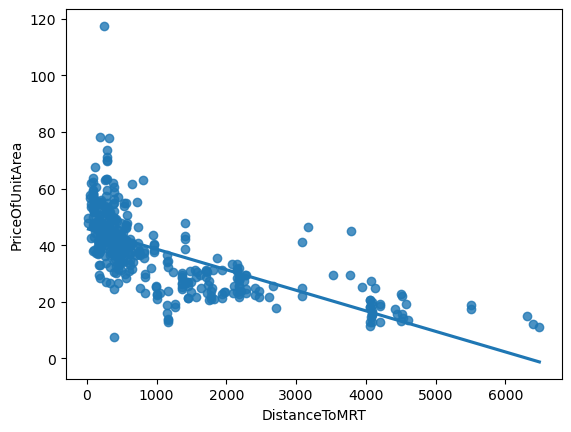

In [33]:
# Model price vs. opening bid using auctions
mdl_price_vs_dist = ols("PriceOfUnitArea ~ DistanceToMRT", data = taiwan_df).fit()

# See the result
print(mdl_price_vs_dist.params)

# Plot the scatter plot pf price vs. openbid with a linear trend line
sns.regplot(x = "DistanceToMRT", y = "PriceOfUnitArea", data = taiwan_df, ci = None)

# Show the plot
plt.show()

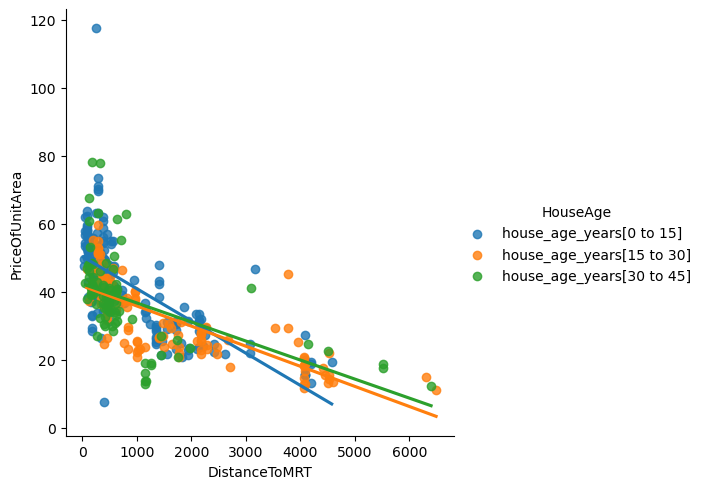

In [34]:
# Fit linear regression of price vs. opening bid and auction type, with an interaction, without intercept
mdl_price_vs_both = ols("PriceOfUnitArea ~ HouseAge + DistanceToMRT:HouseAge + 0", data=taiwan_df).fit()

# Using auctions, plot price vs. opening bid colored by auction type as a scatter plot with linear regr'n trend lines
sns.lmplot(x = "DistanceToMRT", y = "PriceOfUnitArea", data = taiwan_df, hue = "HouseAge", ci = None)

# Show the plot
plt.show()


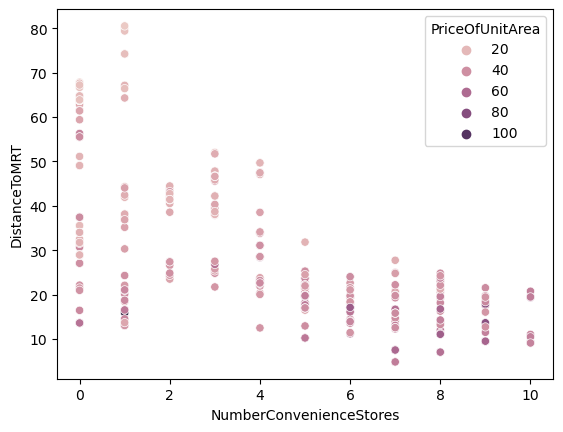

In [35]:
# Transform dist_to_mrt_m to sqrt_dist_to_mrt_m
taiwan_df["DistanceToMRT"] = np.sqrt(taiwan_df["DistanceToMRT"])

# Draw a scatter plot of sqrt_dist_to_mrt_m vs. n_convenience colored by price_twd_msq
sns.scatterplot(x = "NumberConvenienceStores", y = "DistanceToMRT",  hue = "PriceOfUnitArea", data = taiwan_df)

# Show the plot
plt.show()

Using color for the numeric response variable is a great alternative for 3D scatter plots. The plot suggests that prices are higher when more convenience stores are nearby or when the distance to the nearest MRT station is short. Additionally, there tend to be more convenience stores when the nearest MRT station is close.

In [36]:
# Fit linear regression of price vs. no. of conv. stores and sqrt dist. to nearest MRT, no interaction
mdl_price_vs_conv_dist = ols("PriceOfUnitArea ~ NumberConvenienceStores + DistanceToMRT", data=taiwan_df).fit()

# Create n_convenience as an array of numbers from 0 to 10
n_convenience = np.arange(0, 11)

# Create sqrt_dist_to_mrt_m as an array of numbers from 0 to 80 in steps of 10
sqrt_dist_to_mrt_m = np.arange(0, 81, 10)

# Create p as all combinations of values of n_convenience and sqrt_dist_to_mrt_m
p = product(n_convenience, sqrt_dist_to_mrt_m)

# Transform p to a DataFrame and name the columns
explanatory_data = pd.DataFrame(p, columns = ["NumberConvenienceStores", "DistanceToMRT"])

# Add column of predictions
prediction_data = explanatory_data.assign(PriceOfUnitArea = mdl_price_vs_conv_dist.predict(explanatory_data))

# See the result  
print(prediction_data)

    NumberConvenienceStores  DistanceToMRT  PriceOfUnitArea
0                         0              0        49.918025
1                         0             10        44.719250
2                         0             20        39.520475
3                         0             30        34.321700
4                         0             40        29.122925
..                      ...            ...              ...
94                       10             40        36.202918
95                       10             50        31.004143
96                       10             60        25.805368
97                       10             70        20.606593
98                       10             80        15.407819

[99 rows x 3 columns]


To visualize two numeric explanatory variables, create a layer of the actual data points, and add a layer of the prediction points to see how they match.

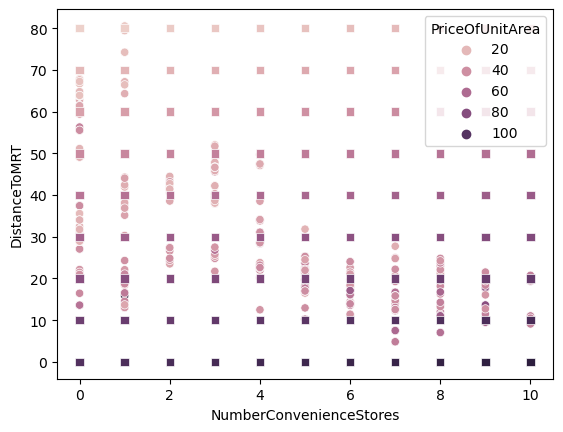

In [37]:
# Create scatter plot of taiwan_real_estate
sns.scatterplot(x = "NumberConvenienceStores", y = "DistanceToMRT", hue = "PriceOfUnitArea", data = taiwan_df)

# Create scatter plot of prediction_data without legend
sns.scatterplot(x = "NumberConvenienceStores", y = "DistanceToMRT",hue = "PriceOfUnitArea", data = prediction_data, marker = "s", legend = False)

# Show the plot
plt.show()

Plotting a colored grid of predictions can give you a general idea of how your model performs. The prediction grid confirms that your model is a good fit: prices are higher when more convenience stores are nearby or when the distance to the nearest MRT station is short.

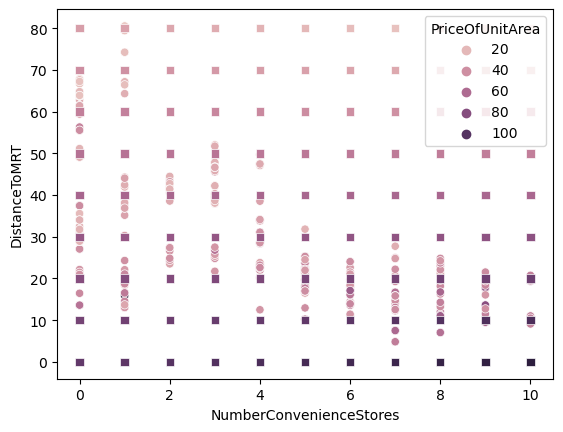

In [38]:
# Convert to mdl_price_vs_conv_dist_inter
mdl_price_vs_conv_dist_inter = ols("PriceOfUnitArea ~ NumberConvenienceStores * DistanceToMRT", data=taiwan_df).fit()

# Use mdl_price_vs_conv_dist_inter to make predictions
n_convenience = np.arange(0, 11)
sqrt_dist_to_mrt_m = np.arange(0, 81, 10)
p = product(n_convenience, sqrt_dist_to_mrt_m)
explanatory_data = pd.DataFrame(p, columns=["NumberConvenienceStores", "DistanceToMRT"])
prediction_data = explanatory_data.assign(
    PriceOfUnitArea = mdl_price_vs_conv_dist_inter.predict(explanatory_data))

# Create scatter plot of taiwan_real_estate
sns.scatterplot(x = "NumberConvenienceStores", y = "DistanceToMRT", hue = "PriceOfUnitArea", data = taiwan_df)

# Create scatter plot of prediction_data without legend
sns.scatterplot(x = "NumberConvenienceStores", y = "DistanceToMRT",hue = "PriceOfUnitArea", data = prediction_data, marker = "s", legend = False)

# Show the plot
plt.show()

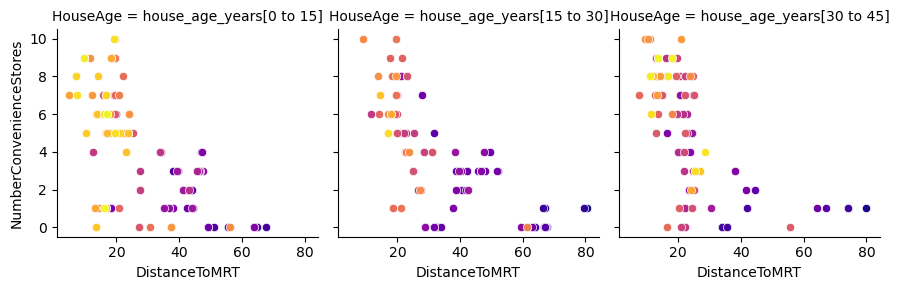

In [39]:
# Prepare the grid using taiwan_real_estate, for each house age category, colored by price_twd_msq
grid = sns.FacetGrid(data=taiwan_df,
            col="HouseAge",
            hue="PriceOfUnitArea",
            palette="plasma")

# Plot the scatterplots with sqrt_dist_to_mrt_m on the x-axis and n_convenience on the y-axis
grid.map(sns.scatterplot,
         "DistanceToMRT",
         "NumberConvenienceStores")

# Show the plot (brighter colors mean higher prices)
plt.show()

In [40]:
# Model price vs. no. of conv. stores, sqrt dist. to MRT station & house age, no global intercept, no interactions
mdl_price_vs_all_no_inter = ols("PriceOfUnitArea ~ NumberConvenienceStores + DistanceToMRT + HouseAge + 0", data=taiwan_df).fit()

# See the result
print(mdl_price_vs_all_no_inter.params)

HouseAge[house_age_years[0 to 15]]     51.100938
HouseAge[house_age_years[15 to 30]]    46.813308
HouseAge[house_age_years[30 to 45]]    45.704452
NumberConvenienceStores                 0.841887
DistanceToMRT                          -0.491149
dtype: float64


In [41]:
# Model price vs. sqrt dist. to MRT station, no. of conv. stores & house age, no global intercept, 3-way interactions
mdl_price_vs_all_3_way_inter = ols("PriceOfUnitArea ~ NumberConvenienceStores * DistanceToMRT * HouseAge + 0", data = taiwan_df).fit()

# See the result
print(mdl_price_vs_all_3_way_inter.params)


HouseAge[house_age_years[0 to 15]]                                             53.100083
HouseAge[house_age_years[15 to 30]]                                            45.468094
HouseAge[house_age_years[30 to 45]]                                            40.092657
NumberConvenienceStores                                                         1.243684
NumberConvenienceStores:HouseAge[T.house_age_years[15 to 30]]                   0.314281
NumberConvenienceStores:HouseAge[T.house_age_years[30 to 45]]                   0.066984
DistanceToMRT                                                                  -0.540399
DistanceToMRT:HouseAge[T.house_age_years[15 to 30]]                             0.124923
DistanceToMRT:HouseAge[T.house_age_years[30 to 45]]                             0.196888
NumberConvenienceStores:DistanceToMRT                                          -0.029628
NumberConvenienceStores:DistanceToMRT:HouseAge[T.house_age_years[15 to 30]]    -0.013487
NumberConvenienceStor

In [42]:
# Model price vs. sqrt dist. to MRT station, no. of conv. stores & house age, no global intercept, 2-way interactions
mdl_price_vs_all_2_way_inter = ols("PriceOfUnitArea ~ (NumberConvenienceStores + HouseAge + DistanceToMRT) ** 2 + 0 ", data = taiwan_df).fit()

# See the result
print(mdl_price_vs_all_2_way_inter.params)

HouseAge[house_age_years[0 to 15]]                               53.085716
HouseAge[house_age_years[15 to 30]]                              45.962907
HouseAge[house_age_years[30 to 45]]                              39.243138
NumberConvenienceStores                                           1.250719
NumberConvenienceStores:HouseAge[T.house_age_years[15 to 30]]     0.002065
NumberConvenienceStores:HouseAge[T.house_age_years[30 to 45]]     0.523468
DistanceToMRT                                                    -0.539746
HouseAge[T.house_age_years[15 to 30]]:DistanceToMRT               0.107686
HouseAge[T.house_age_years[30 to 45]]:DistanceToMRT               0.237451
NumberConvenienceStores:DistanceToMRT                            -0.030026
dtype: float64


In [43]:
# Create n_convenience as an array of numbers from 0 to 10
n_convenience = np.arange(0, 11)

# Create sqrt_dist_to_mrt_m as an array of numbers from 0 to 80 in steps of 10
sqrt_dist_to_mrt_m = np.arange(0, 81, 10)

# Create house_age_years with unique values
house_age_years = taiwan_df["HouseAge"].unique()

# Create p as all combinations of n_convenience, sqrt_dist_to_mrt_m, and house_age_years, in that order
p = product(n_convenience, sqrt_dist_to_mrt_m, house_age_years)

# Transform p to a DataFrame and name the columns
explanatory_data = pd.DataFrame(p, columns=["NumberConvenienceStores",
                                            "DistanceToMRT",
                                            "HouseAge"])

# Add column of predictions
prediction_data = explanatory_data.assign(
    PriceOfUnitArea = mdl_price_vs_all_3_way_inter.predict(explanatory_data)
)
# See the result
print(prediction_data)

     NumberConvenienceStores  DistanceToMRT                   HouseAge  \
0                          0              0  house_age_years[30 to 45]   
1                          0              0  house_age_years[15 to 30]   
2                          0              0   house_age_years[0 to 15]   
3                          0             10  house_age_years[30 to 45]   
4                          0             10  house_age_years[15 to 30]   
..                       ...            ...                        ...   
292                       10             70  house_age_years[15 to 30]   
293                       10             70   house_age_years[0 to 15]   
294                       10             80  house_age_years[30 to 45]   
295                       10             80  house_age_years[15 to 30]   
296                       10             80   house_age_years[0 to 15]   

     PriceOfUnitArea  
0          40.092657  
1          45.468094  
2          53.100083  
3          36.65753

Linear regression minimizes the sum of the squares of the differences between the actual responses and the predicted responses. Sum of squares is a measure of how far the predicted responses are from the actual responses. 

In [44]:
x_actual = taiwan_df['NumberConvenienceStores']
y_actual = taiwan_df['PriceOfUnitArea']

# Complete the function to calculate sum of squares
def calc_sum_of_squares(coeffs):
    # Unpack coeffs
    intercept, slope = coeffs
    # Calculate predicted y-values
    y_pred = intercept + slope * x_actual
    # Calculate differences between y_pred and y_actual
    y_diff = y_pred - y_actual
    # Calculate sum of squares
    sum_sq = np.sum(y_diff**2)
    # Return sum of squares
    return sum_sq
  
# Test the function with intercept 10 and slope 1
print(calc_sum_of_squares([10, 1]))

297345.33999999997


In [45]:
# Call minimize on calc_sum_of_squares  
print(minimize(fun=calc_sum_of_squares,
               x0=[0, 0]))

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 51531.40474086568
        x: [ 2.718e+01  2.638e+00]
      nit: 8
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 1.123e-03 -1.629e-04]
            [-1.629e-04  7.207e-05]]
     nfev: 60
     njev: 20


In [46]:
# Compare the output with the ols() call.
print(ols("PriceOfUnitArea ~ NumberConvenienceStores", data=taiwan_df).fit().params)
  

Intercept                  27.181105
NumberConvenienceStores     2.637653
dtype: float64
